<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/DailyChallengeW5D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Importation des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
    Flatten
)
from tensorflow.keras.utils import to_categorical

### 2. Chargement du jeu de données MNIST

In [2]:
# Chargement des données
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.mnist.load_data()
)

# Affichage des dimensions
print("Forme de x_train :", x_train.shape)
print("Forme de y_train :", y_train.shape)
print("Forme de x_test  :", x_test.shape)
print("Forme de y_test  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme de x_train : (60000, 28, 28)
Forme de y_train : (60000,)
Forme de x_test  : (10000, 28, 28)
Forme de y_test  : (10000,)


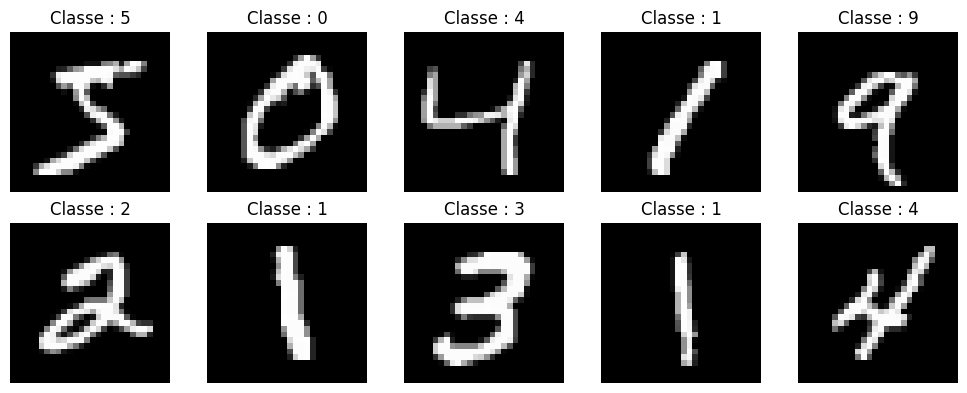

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Classe : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Partie 1: Réseau de neurones entièrement connecté

### 3. Prétraitement pour le réseau dense

In [6]:
# Sauvegarde des étiquettes originales
y_train_original = y_train.copy()
y_test_original = y_test.copy()

# Aplatissement des images : 28 × 28 devient 784
x_train_dense = x_train.reshape(x_train.shape[0], 784)
x_test_dense = x_test.reshape(x_test.shape[0], 784)

# Conversion en nombres flottants et normalisation
x_train_dense = x_train_dense.astype("float32") / 255.0
x_test_dense = x_test_dense.astype("float32") / 255.0

# Encodage one-hot des étiquettes
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print("Forme de x_train_dense :", x_train_dense.shape)
print("Forme de y_train_encoded :", y_train_encoded.shape)

print("Étiquette originale :", y_train_original[0])
print("Étiquette one-hot   :", y_train_encoded[0])

Forme de x_train_dense : (60000, 784)
Forme de y_train_encoded : (60000, 10)
Étiquette originale : 5
Étiquette one-hot   : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 4. Construction du réseau dense

In [7]:
dense_model = Sequential([
    Input(shape=(784,)),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(10, activation="softmax")
])

dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Compilation du modèle dense

In [8]:
dense_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### 6. Entraînement du modèle dense

In [9]:
dense_history = dense_model.fit(
    x_train_dense,
    y_train_encoded,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8551 - loss: 0.4792 - val_accuracy: 0.9592 - val_loss: 0.1488
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.2099 - val_accuracy: 0.9675 - val_loss: 0.1124
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9525 - loss: 0.1614 - val_accuracy: 0.9737 - val_loss: 0.0914
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9612 - loss: 0.1284 - val_accuracy: 0.9768 - val_loss: 0.0812
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9660 - loss: 0.1120 - val_accuracy: 0.9767 - val_loss: 0.0798


### 7. Évaluation du modèle dense

In [10]:
dense_loss, dense_accuracy = dense_model.evaluate(
    x_test_dense,
    y_test_encoded,
    verbose=0
)

print("Perte du réseau dense :", dense_loss)
print("Précision du réseau dense :", dense_accuracy)

Perte du réseau dense : 0.08777811378240585
Précision du réseau dense : 0.972100019454956


## Partie 2 — Réseau de neurones convolutif

### 8. Prétraitement pour le CNN

In [11]:
# Ajout de la dimension correspondant au canal
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Conversion et normalisation
x_train_cnn = x_train_cnn.astype("float32") / 255.0
x_test_cnn = x_test_cnn.astype("float32") / 255.0

print("Forme de x_train_cnn :", x_train_cnn.shape)
print("Forme de x_test_cnn :", x_test_cnn.shape)

Forme de x_train_cnn : (60000, 28, 28, 1)
Forme de x_test_cnn : (10000, 28, 28, 1)


### 9. Construction du CNN

In [12]:
cnn_model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 10. Compilation du CNN

In [13]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### 11. Entraînement du CNN

In [14]:
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train_encoded,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.9203 - loss: 0.2613 - val_accuracy: 0.9810 - val_loss: 0.0682
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9769 - loss: 0.0768 - val_accuracy: 0.9857 - val_loss: 0.0514
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9822 - loss: 0.0567 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.9869 - loss: 0.0439 - val_accuracy: 0.9872 - val_loss: 0.0446
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9905 - val_loss: 0.0366


### 12. Évaluation du CNN

In [15]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    x_test_cnn,
    y_test_encoded,
    verbose=0
)

print("Perte du CNN :", cnn_loss)
print("Précision du CNN :", cnn_accuracy)

Perte du CNN : 0.027270672842860222
Précision du CNN : 0.9909999966621399


### 13. Comparaison des deux modèles

In [16]:
print("\n----- Comparaison des modèles -----")

print(f"Réseau dense")
print(f"  Perte     : {dense_loss:.4f}")
print(f"  Précision : {dense_accuracy * 100:.2f} %")

print(f"\nCNN")
print(f"  Perte     : {cnn_loss:.4f}")
print(f"  Précision : {cnn_accuracy * 100:.2f} %")

difference = (cnn_accuracy - dense_accuracy) * 100

print(f"\nDifférence de précision : {difference:.2f} points")


----- Comparaison des modèles -----
Réseau dense
  Perte     : 0.0878
  Précision : 97.21 %

CNN
  Perte     : 0.0273
  Précision : 99.10 %

Différence de précision : 1.89 points


### 14. Graphique de comparaison

In [ ]:
model_names = ["Réseau dense", "CNN"]
accuracies = [dense_accuracy, cnn_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(model_names, accuracies)

plt.title("Comparaison des précisions sur les données de test")
plt.ylabel("Précision")
plt.ylim(0.90, 1.0)

for index, accuracy in enumerate(accuracies):
    plt.text(
        index,
        accuracy + 0.002,
        f"{accuracy * 100:.2f} %",
        ha="center"
    )

plt.show()

### 15. Courbes d’apprentissage

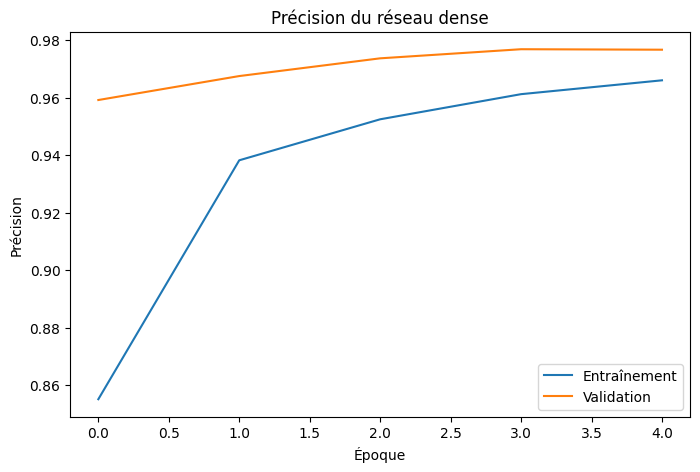

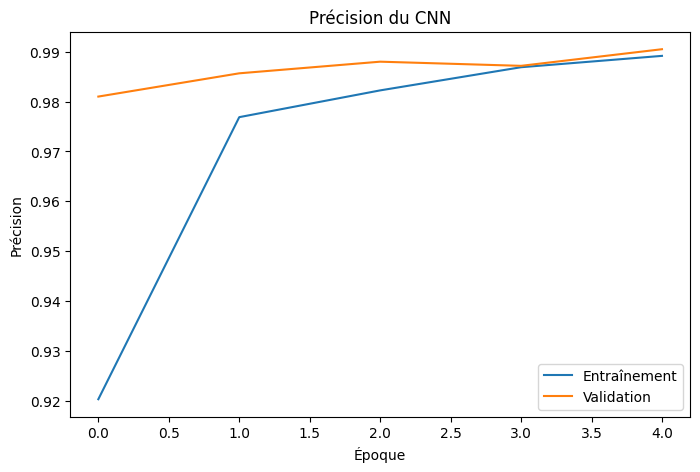

In [18]:
#Reseau de neurone dense

plt.figure(figsize=(8, 5))

plt.plot(
    dense_history.history["accuracy"],
    label="Entraînement"
)

plt.plot(
    dense_history.history["val_accuracy"],
    label="Validation"
)

plt.title("Précision du réseau dense")
plt.xlabel("Époque")
plt.ylabel("Précision")
plt.legend()
plt.show()

#courbe CNN

plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Entraînement"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation"
)

plt.title("Précision du CNN")
plt.xlabel("Époque")
plt.ylabel("Précision")
plt.legend()
plt.show()

### 16. Effectuer des prédictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prédictions : [7 2 1 0 4 1 4 9 5 9]
Vraies classes : [7 2 1 0 4 1 4 9 5 9]


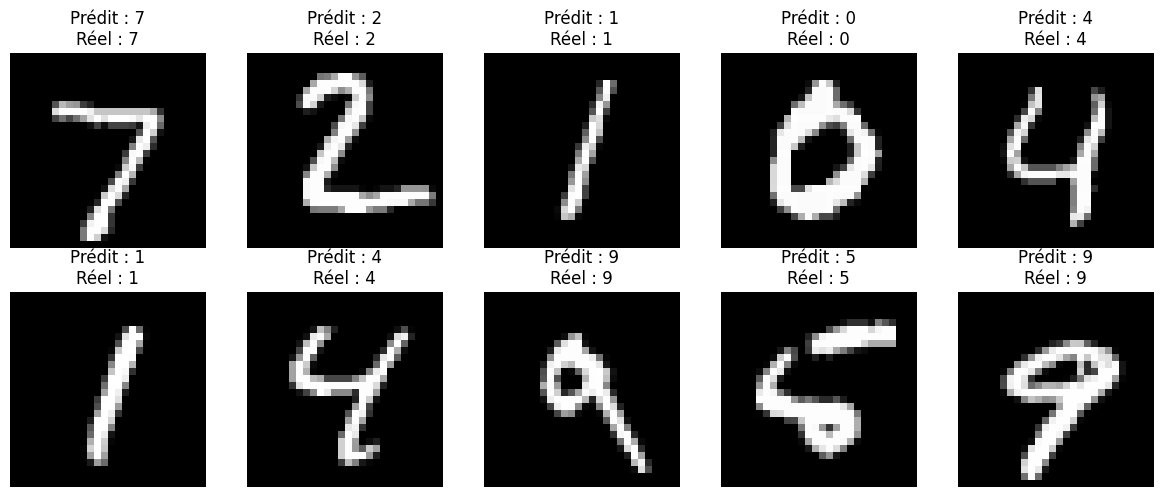

In [19]:
# Prédictions sur les 10 premières images
probabilities = cnn_model.predict(x_test_cnn[:10])

# Récupération de la classe ayant la probabilité la plus élevée
predictions = np.argmax(probabilities, axis=1)

print("Prédictions :", predictions)
print("Vraies classes :", y_test_original[:10])

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i], cmap="gray")

    predicted_class = predictions[i]
    actual_class = y_test_original[i]

    plt.title(
        f"Prédit : {predicted_class}\nRéel : {actual_class}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()
